In [21]:
import seaborn as sns
import pandas as pd

In [22]:
import re

raw = """
Inject  Latency Bandwidth
Delay   (ns)    MB/sec
==========================
 00700  2321.73  35047.5
 01000  1943.82  29525.9
 01300  1555.08  25800.1
 01700  1088.48  21780.0
 02500  751.21   16991.5
 03500  618.27   13200.8
 05000  516.60    9837.1
 09000  403.88    6009.0
 20000  345.04    2935.5
"""

latency = []
bandwidth = []

for line in raw.splitlines():
    m = re.search(r'(\d+\.\d+)\s+(\d+\.\d+)\s*$', line)
    if m:
        latency.append(float(m.group(1)))
        bandwidth.append(float(m.group(2)))

In [23]:
df = pd.DataFrame({'Latency (ns)': latency, 'Bandwidth (MB/s)': bandwidth})

<Axes: xlabel='Bandwidth (MB/s)', ylabel='Latency (ns)'>

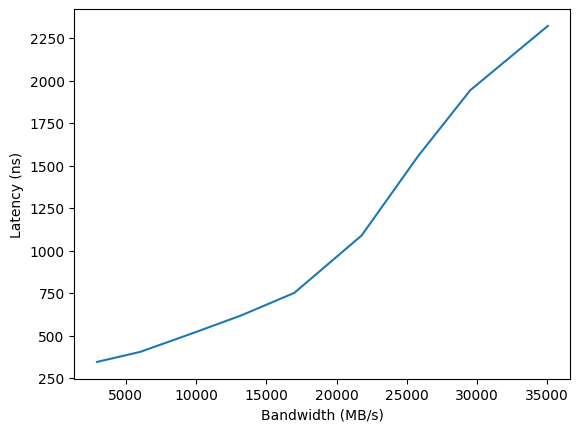

In [24]:
sns.lineplot(data=df, x='Bandwidth (MB/s)', y='Latency (ns)')

Two-slope continuous fit (requested):
  knee (GB/s):      17.139
  slope1 (us/GB/s): 0.02986
  slope2 (us/GB/s): 0.09511
  lat@knee (us):    0.753

Defs.h-compatible fit (flat then linear):
  UNLOADED_NVM_LAT: 0.42182
  NVM_RD_BW_KNEE:   11.919
  NVM_BW_SLOPE:     0.08516


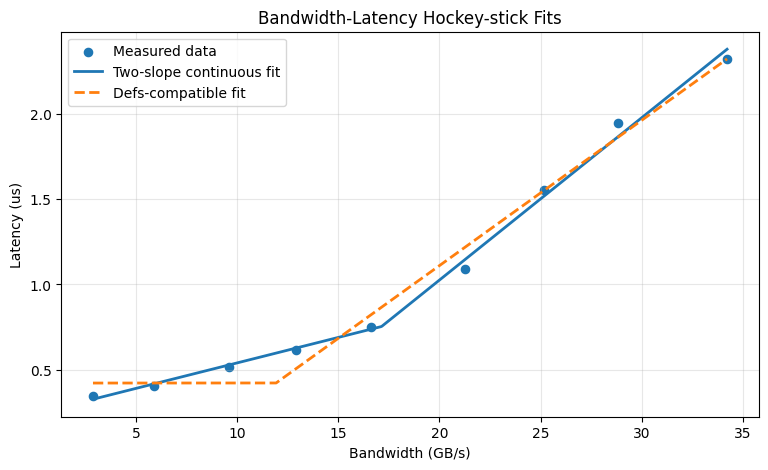

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to model units used in defs.h
x = (df['Bandwidth (MB/s)'].to_numpy() / 1024.0)  # GB/s
y = (df['Latency (ns)'].to_numpy() / 1000.0)      # us

order = np.argsort(x)
x = x[order]
y = y[order]

def fit_two_slope_continuous(x, y, n_grid=4000):
    # y = a + m1*x + d*max(0, x-k), where slope2 = m1 + d
    k_grid = np.linspace(float(x.min()) + 1e-6, float(x.max()) - 1e-6, n_grid)
    best = None
    for k in k_grid:
        z = np.maximum(0.0, x - k)
        A = np.column_stack([np.ones_like(x), x, z])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        pred = A @ coef
        sse = float(np.sum((pred - y) ** 2))
        if best is None or sse < best[0]:
            best = (sse, k, coef, pred)
    sse, k, coef, pred = best
    a, m1, d = coef
    m2 = m1 + d
    yk = a + m1 * k
    return {
        'sse': sse,
        'knee': float(k),
        'm1': float(m1),
        'm2': float(m2),
        'a': float(a),
        'lat_at_knee': float(yk),
        'pred': pred,
    }

def fit_defs_hockeystick(x, y, n_grid=5000):
    # Current code model: y = a + s*max(0, x-k)
    k_grid = np.linspace(float(x.min()) + 1e-6, float(x.max()) - 1e-6, n_grid)
    best = None
    for k in k_grid:
        z = np.maximum(0.0, x - k)
        A = np.column_stack([np.ones_like(x), z])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        pred = A @ coef
        sse = float(np.sum((pred - y) ** 2))
        if best is None or sse < best[0]:
            best = (sse, k, coef, pred)
    sse, k, coef, pred = best
    a, s = coef
    return {
        'sse': sse,
        'knee': float(k),
        'unloaded': float(a),
        'slope': float(s),
        'pred': pred,
    }

two = fit_two_slope_continuous(x, y)
one = fit_defs_hockeystick(x, y)

print('Two-slope continuous fit (requested):')
print(f"  knee (GB/s):      {two['knee']:.3f}")
print(f"  slope1 (us/GB/s): {two['m1']:.5f}")
print(f"  slope2 (us/GB/s): {two['m2']:.5f}")
print(f"  lat@knee (us):    {two['lat_at_knee']:.3f}")

print('\nDefs.h-compatible fit (flat then linear):')
print(f"  UNLOADED_NVM_LAT: {one['unloaded']:.5f}")
print(f"  NVM_RD_BW_KNEE:   {one['knee']:.3f}")
print(f"  NVM_BW_SLOPE:     {one['slope']:.5f}")

xx = np.linspace(x.min(), x.max(), 600)
yy_two = two['a'] + two['m1'] * xx + (two['m2'] - two['m1']) * np.maximum(0.0, xx - two['knee'])
yy_one = one['unloaded'] + one['slope'] * np.maximum(0.0, xx - one['knee'])

plt.figure(figsize=(9, 5))
plt.scatter(x, y, label='Measured data', s=35)
plt.plot(xx, yy_two, label='Two-slope continuous fit', linewidth=2)
plt.plot(xx, yy_one, label='Defs-compatible fit', linewidth=2, linestyle='--')
plt.xlabel('Bandwidth (GB/s)')
plt.ylabel('Latency (us)')
plt.title('Bandwidth-Latency Hockey-stick Fits')
plt.grid(alpha=0.3)
plt.legend()
plt.show()